In [0]:
import matplotlib.pyplot as plt

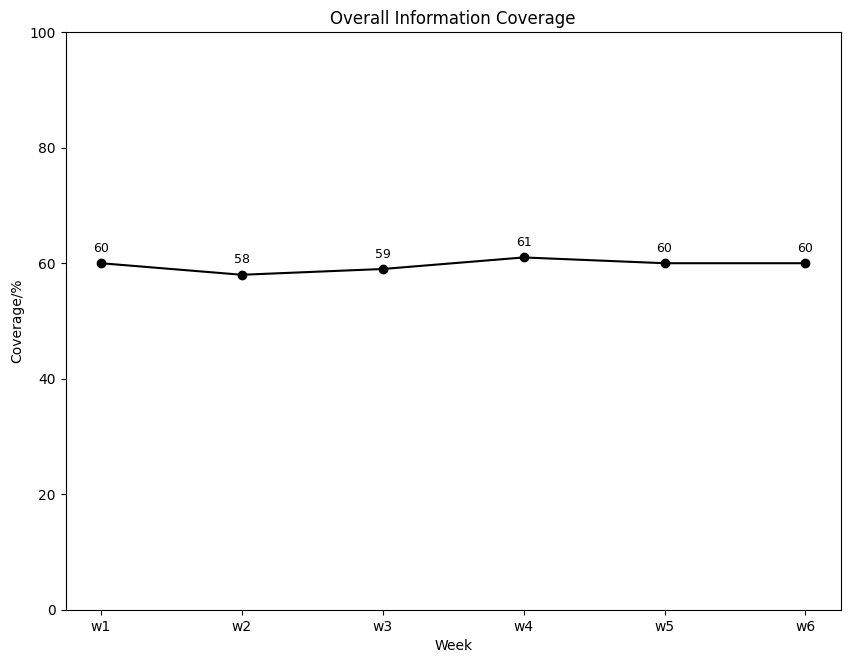

In [0]:
# understand overall information coverage metric movement
weeks = ["w1","w2","w3","w4","w5","w6"]

df_overall = {
                "info_coverage": [60, 58, 59, 61, 60, 60]
             }

plt.figure(figsize=(10,7.5))

for k, v in df_overall.items():
    plt.plot(
        weeks,
        v,
        marker='o',
        color='black',
        label=k
    )
  
    for i, val in enumerate(v):
      plt.text(weeks[i], val + 2, str(val), ha='center', fontsize=9)

plt.title("Overall Information Coverage")
plt.xlabel("Week")
plt.ylabel("Coverage/%")
plt.ylim(0, 100)

plt.show()

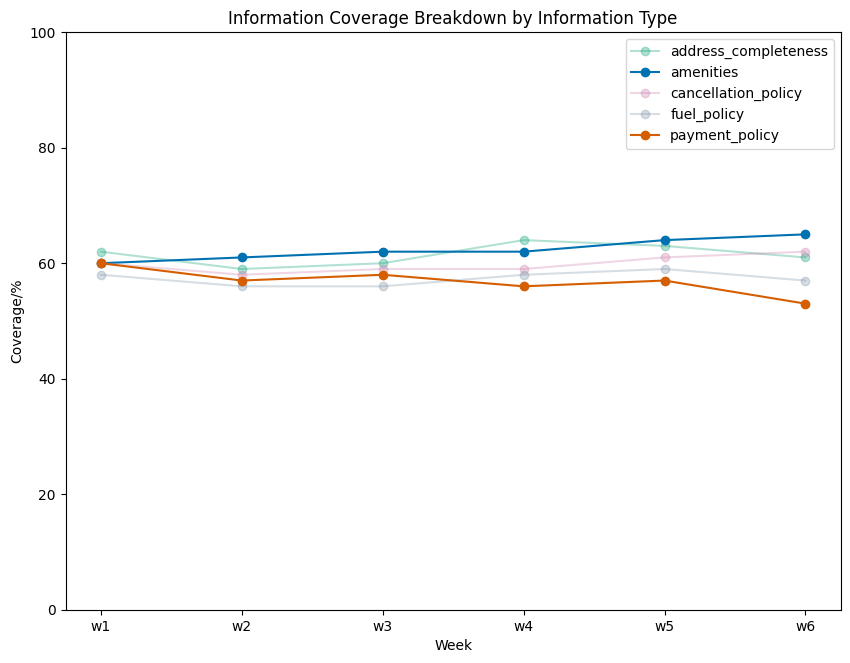

In [0]:
# break information coverage metric into its components of information type
df_breakdown = {
    "address_completeness": [62, 59, 60, 64, 63, 61],
    "amenities": [60, 61, 62, 62, 64, 65],
    "cancellation_policy": [60, 58, 59, 59, 61, 62],
    "fuel_policy": [58, 56, 56, 58, 59, 57],
    "payment_policy": [60, 57, 58, 56, 57, 53],
}

# colour blind friendly palette
colours = {
    "address_completeness": "#009E73",   # green
    "amenities": "#0072B2",              # blue
    "cancellation_policy": "#CC79A7",    # purple
    "fuel_policy": "#7A8FA3",            # muted grey-blue
    "payment_policy": "#D55E00",         # vermillion
}

plt.figure(figsize=(10,7.5))

for k, v in df_breakdown.items():
    if k in ["amenities", "payment_policy"]:
        plt.plot(weeks, v, marker='o', label=k, color=colours[k], alpha=1.0)
    else:
        plt.plot(weeks, v, marker='o', label=k, color=colours[k], alpha=0.3)

plt.title("Information Coverage Breakdown by Information Type")
plt.xlabel("Week")
plt.ylabel("Coverage/%")
plt.ylim(0, 100)
plt.legend()

plt.show()

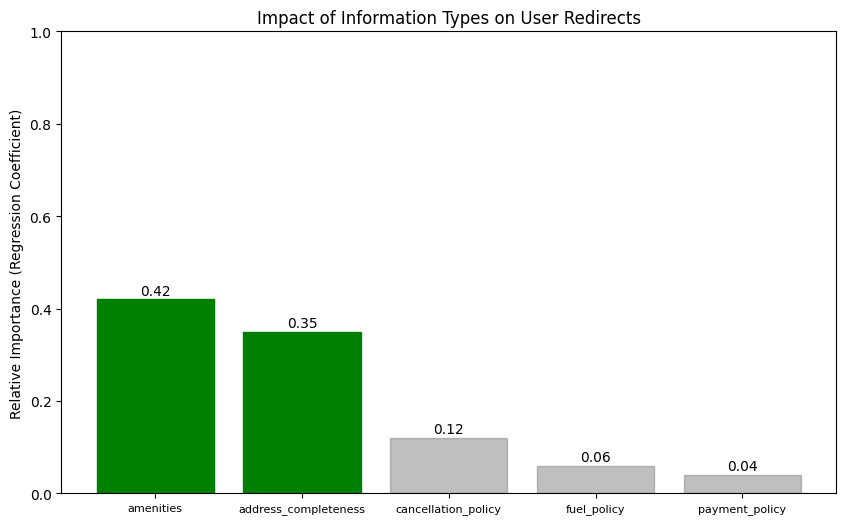

In [0]:
# linear regression to understand which information type(s) play a bigger part in driving user redirects
coeffs = {
              "amenities": 0.42,
              "address_completeness": 0.35,
              "cancellation_policy": 0.12,
              "fuel_policy": 0.06,
              "payment_policy": 0.04,
          }

labels = list(coeffs.keys())
values = list(coeffs.values())

plt.figure(figsize=(10,6))

bars = plt.bar(labels, values)

# highlight top drivers
for i, bar in enumerate(bars):
    if labels[i] in ["amenities", "address_completeness"]:
        bar.set_color("green")
    else:
        bar.set_color("gray")
        bar.set_alpha(0.5)

# add value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.title("Impact of Information Types on User Redirects")
plt.ylabel("Relative Importance (Regression Coefficient)")

plt.ylim(0, 1)
plt.xticks(fontsize=8)

plt.show()